# Phase 3  Drop-off Analysis

**Goal:** Understand WHO is dropping off, WHERE, and WHY.

By the end of this notebook you will know:
- Which users dropped at each funnel stage
- The price characteristics of abandoned carts
- Which categories have the highest abandonment
- How to frame these findings as business problems

---

## Core Concept: The Leaky Bucket

Imagine your funnel is a bucket with holes.

```
[WATER POURED IN]  → All users who view a product
    |
    | (hole 1: view-to-cart drop-off)
    |
[LEVEL 2]          → Users who add to cart
    |
    | (hole 2: cart-to-purchase drop-off)
    |
[COLLECTED WATER]  → Purchases
```

**Drop-off analysis = finding the holes and measuring their size.**

Knowing WHERE the hole is tells you WHAT to fix:
- Big hole at view-to-cart → product pages aren't compelling
- Big hole at cart-to-purchase → checkout friction, price shock, trust issues

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df_full = pd.read_csv("../data/2019-Oct.csv")
all_user_ids = df_full["user_id"].unique()
sampled_users = pd.Series(all_user_ids).sample(n=50_000, random_state=42)
df = df_full[df_full["user_id"].isin(sampled_users)].copy()
df["event_time"] = pd.to_datetime(df["event_time"])

print("Data loaded.")

Data loaded.


## Step 1  Identify users at each stage using sets

Python sets let us do fast membership operations  who is in stage A but not stage B.

In [12]:
view_users     = set(df[df["event_type"] == "view"]["user_id"])
cart_users     = set(df[df["event_type"] == "cart"]["user_id"]) & view_users
purchase_users = set(df[df["event_type"] == "purchase"]["user_id"]) & cart_users
# Drop-off groups
view_only_users      = view_users - cart_users          # saw product, never carted
cart_abandoned_users = cart_users - purchase_users      # carted, never bought
full_funnel_users    = purchase_users                   # completed all 3 stages

print(f"FUNNEL SEGMENT SIZES")
print(f"{'─'*45}")
print(f"  View only (never carted)     : {len(view_only_users):,}")
print(f"  Cart abandoned (never bought): {len(cart_abandoned_users):,}")
print(f"  Completed purchase           : {len(full_funnel_users):,}")
print()
print(f"  Total unique users in dataset: {len(view_users | cart_users | purchase_users):,}")

FUNNEL SEGMENT SIZES
─────────────────────────────────────────────
  View only (never carted)     : 44,569
  Cart abandoned (never bought): 2,174
  Completed purchase           : 3,252

  Total unique users in dataset: 49,995


## Step 2  Cart abandonment price analysis

**Hypothesis to test:** Are users abandoning carts because products are too expensive?

If abandoned carts contain higher-priced items than completed purchases → price is a likely factor.

**This is how real analysts think: state a hypothesis, then test it with data.**

In [13]:
# Prices of items in abandoned carts
abandoned_cart_prices  = df[
    (df["event_type"] == "cart") & (df["user_id"].isin(cart_abandoned_users))
]["price"].dropna()

# Prices of items in completed purchases
purchased_prices = df[
    (df["event_type"] == "purchase") & (df["user_id"].isin(full_funnel_users))
]["price"].dropna()

print("ABANDONED CART  Price Statistics:")
print(abandoned_cart_prices.describe().round(2))
print()
print("COMPLETED PURCHASE  Price Statistics:")
print(purchased_prices.describe().round(2))
print()

median_abandoned  = abandoned_cart_prices.median()
median_purchased  = purchased_prices.median()
print(f"Median abandoned cart price : ${median_abandoned:.2f}")
print(f"Median completed purchase   : ${median_purchased:.2f}")
if median_abandoned > median_purchased * 1.1:
    print()
    print("FINDING: Abandoned carts have significantly higher median prices.")
    print("         This supports a PRICE SENSITIVITY hypothesis.")
else:
    print()
    print("FINDING: Price difference is small. Price alone does not explain abandonment.")

ABANDONED CART  Price Statistics:
count    3907.00
mean      324.30
std       360.47
min         2.55
25%        99.73
50%       189.97
75%       380.67
max      2573.79
Name: price, dtype: float64

COMPLETED PURCHASE  Price Statistics:
count    8154.00
mean      336.63
std       351.58
min         1.00
25%       130.11
50%       215.63
75%       424.68
max      2496.59
Name: price, dtype: float64

Median abandoned cart price : $189.97
Median completed purchase   : $215.63

FINDING: Price difference is small. Price alone does not explain abandonment.


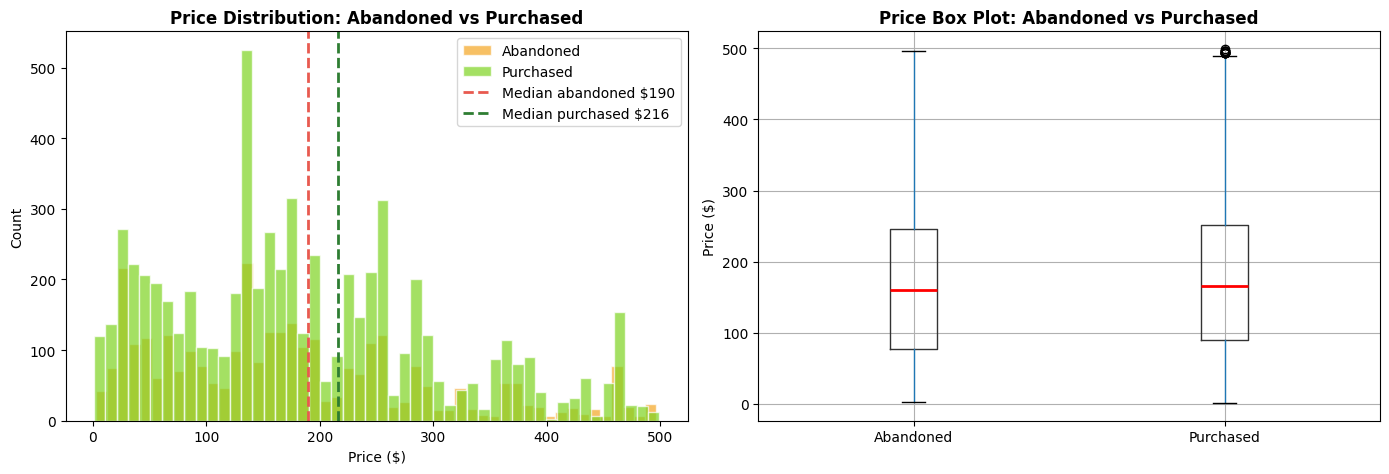

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cap = 500  # cap at $500 for readability

axes[0].hist(abandoned_cart_prices[abandoned_cart_prices < cap],
             bins=50, color="#F5A623", alpha=0.7, label="Abandoned", edgecolor="white")
axes[0].hist(purchased_prices[purchased_prices < cap],
             bins=50, color="#7ED321", alpha=0.7, label="Purchased", edgecolor="white")
axes[0].axvline(median_abandoned, color="#E85A4F", linestyle="--", lw=2,
                label=f"Median abandoned ${median_abandoned:.0f}")
axes[0].axvline(median_purchased, color="#2E7D32", linestyle="--", lw=2,
                label=f"Median purchased ${median_purchased:.0f}")
axes[0].set_title("Price Distribution: Abandoned vs Purchased", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Box plot comparison
price_compare = pd.DataFrame({
    "Price": list(abandoned_cart_prices[abandoned_cart_prices < cap]) +
             list(purchased_prices[purchased_prices < cap]),
    "Group": ["Abandoned"] * len(abandoned_cart_prices[abandoned_cart_prices < cap]) +
             ["Purchased"] * len(purchased_prices[purchased_prices < cap])
})
price_compare.boxplot(column="Price", by="Group", ax=axes[1], 
                      boxprops=dict(color="#333"), medianprops=dict(color="red", lw=2))
axes[1].set_title("Price Box Plot: Abandoned vs Purchased", fontsize=12, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Price ($)")
plt.suptitle("")

plt.tight_layout()
plt.savefig("../outputs/03_price_abandonment.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3  Category-level drop-off

Not all categories drop off equally.
Luxury electronics might have worse conversion than everyday consumables.
Finding this tells you WHERE to focus product and marketing effort.

In [15]:
# Only rows with valid category info
cat_df = df[df["category_code"].notna()].copy()
cat_df["top_category"] = cat_df["category_code"].str.split(".").str[0]

# Unique users who reached each stage per category
cat_views     = cat_df[cat_df["event_type"] == "view"].groupby("top_category")["user_id"].nunique()
cat_purchases = cat_df[cat_df["event_type"] == "purchase"].groupby("top_category")["user_id"].nunique()

cat_funnel = pd.DataFrame({"views": cat_views, "purchases": cat_purchases}).fillna(0)
cat_funnel = cat_funnel[cat_funnel["views"] >= 1000]  # filter tiny categories
cat_funnel["conversion_rate"] = (cat_funnel["purchases"] / cat_funnel["views"] * 100).round(2)
cat_funnel = cat_funnel.sort_values("conversion_rate", ascending=False)

print("CONVERSION RATE BY CATEGORY (min 1000 views)")
print(cat_funnel.to_string())

CONVERSION RATE BY CATEGORY (min 1000 views)
              views  purchases  conversion_rate
top_category                                   
electronics   27844     3258.0            11.70
appliances     9064      810.0             8.94
computers      4063      262.0             6.45
construction   1696       75.0             4.42
auto           2671      113.0             4.23
kids           1646       61.0             3.71
furniture      3406       92.0             2.70
apparel        4269       77.0             1.80


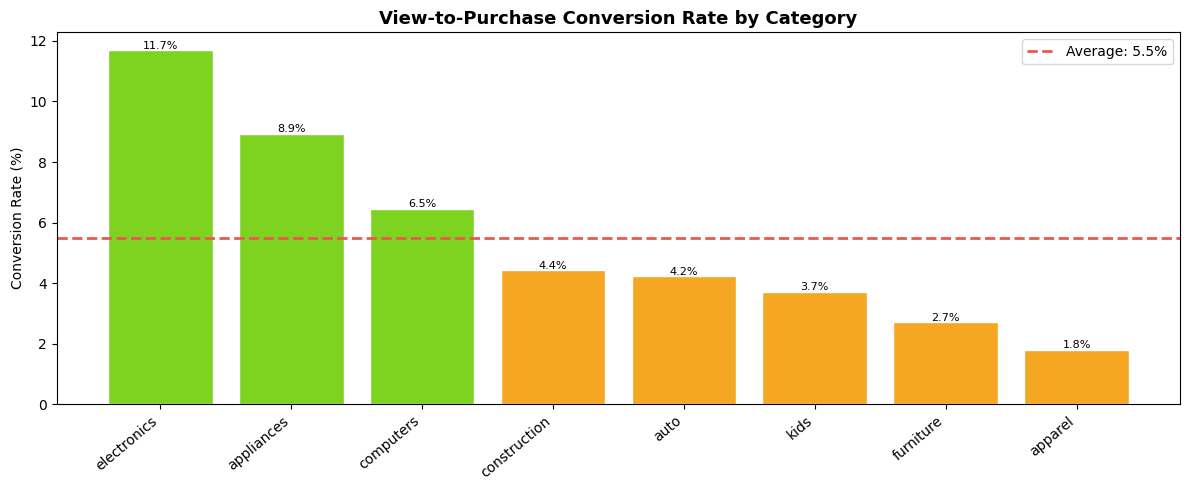

In [16]:
top_cats = cat_funnel.head(12)

plt.figure(figsize=(12, 5))
bars = plt.bar(range(len(top_cats)), top_cats["conversion_rate"],
               color=["#7ED321" if v >= cat_funnel["conversion_rate"].mean() else "#F5A623"
                      for v in top_cats["conversion_rate"]],
               edgecolor="white")

avg_rate = cat_funnel["conversion_rate"].mean()
plt.axhline(avg_rate, color="#E85A4F", linestyle="--", lw=2, label=f"Average: {avg_rate:.1f}%")

plt.xticks(range(len(top_cats)), top_cats.index, rotation=40, ha="right")
plt.ylabel("Conversion Rate (%)")
plt.title("View-to-Purchase Conversion Rate by Category", fontsize=13, fontweight="bold")
plt.legend()
for bar, val in zip(bars, top_cats["conversion_rate"]):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/03_category_conversion.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 4  Time-of-day analysis

Does the time of day affect purchase likelihood?
If yes → you can optimize ad spend and email timing.

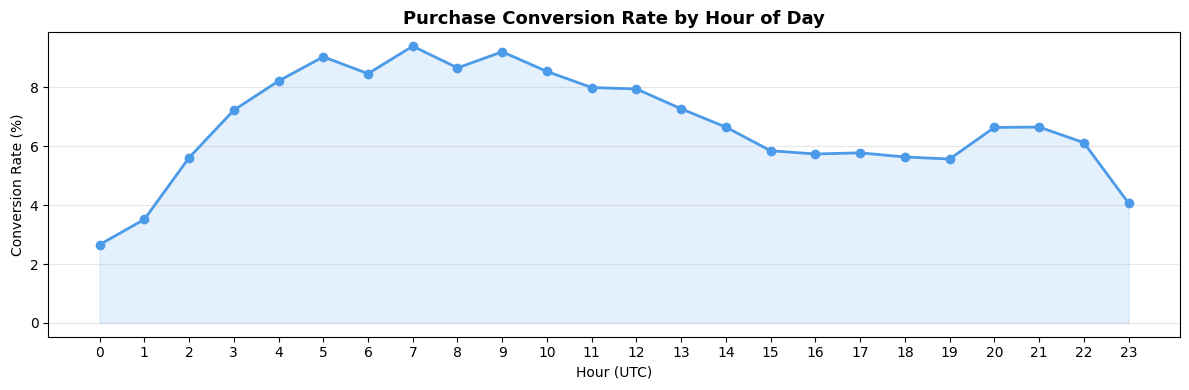

Peak conversion hour: 7:00 UTC  (9.40%)


In [17]:
df["hour"] = df["event_time"].dt.hour

hourly_views     = df[df["event_type"] == "view"].groupby("hour")["user_id"].nunique()
hourly_purchases = df[df["event_type"] == "purchase"].groupby("hour")["user_id"].nunique()
hourly_rate = (hourly_purchases / hourly_views * 100).fillna(0)

plt.figure(figsize=(12, 4))
plt.plot(hourly_rate.index, hourly_rate.values, marker="o", color="#4C9BE8", lw=2)
plt.fill_between(hourly_rate.index, hourly_rate.values, alpha=0.15, color="#4C9BE8")
plt.title("Purchase Conversion Rate by Hour of Day", fontsize=13, fontweight="bold")
plt.xlabel("Hour (UTC)")
plt.ylabel("Conversion Rate (%)")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/03_hourly_conversion.png", dpi=150, bbox_inches="tight")
plt.show()

peak_hour = hourly_rate.idxmax()
print(f"Peak conversion hour: {peak_hour}:00 UTC  ({hourly_rate[peak_hour]:.2f}%)")

## Step 5  Translate findings into GTM language

Raw numbers are not findings. Findings are insights that drive decisions.

Use this framework for each observation:

```
FINDING  → What the data shows (be specific with numbers)
SO WHAT  → Why this matters to the business
ACTION   → What should change
METRIC   → How to measure if the change worked
```

In [18]:
# Summary of findings from this notebook  fill in your actual numbers
print("=" * 60)
print("DROP-OFF ANALYSIS  KEY FINDINGS SUMMARY")
print("=" * 60)
print()

abandoned_median = abandoned_cart_prices.median()
purchased_median = purchased_prices.median()

print(f"FINDING 1: Price in abandoned carts (${abandoned_median:.0f} median) vs")
print(f"           purchased items (${purchased_median:.0f} median).")
if abandoned_median > purchased_median * 1.1:
    print("SO WHAT : Price sensitivity is a real factor in cart abandonment.")
    print("ACTION  : A/B test: show installment payment option at checkout.")
    print("METRIC  : Cart→Purchase rate (target: +5% in 30 days).")
else:
    print("SO WHAT : Price alone doesn't explain abandonment. Look at UX friction.")
    print("ACTION  : Conduct checkout UX audit  look for confusing steps.")
    print("METRIC  : Cart→Purchase rate (target: +3% in 30 days).")
print()

best_cat  = cat_funnel["conversion_rate"].idxmax()
worst_cat = cat_funnel["conversion_rate"].idxmin()
print(f"FINDING 2: '{best_cat}' has the highest conversion rate ({cat_funnel.loc[best_cat,'conversion_rate']:.1f}%).")
print(f"           '{worst_cat}' has the lowest ({cat_funnel.loc[worst_cat,'conversion_rate']:.1f}%).")
print(f"SO WHAT : GTM spend on '{best_cat}' has better ROI  users convert more.")
print(f"ACTION  : Shift paid acquisition budget toward '{best_cat}' category.")
print(f"METRIC  : Revenue per visitor in '{best_cat}' (target: maintain or grow).")
print()
print(f"FINDING 3: Peak purchase hour is {peak_hour}:00 UTC.")
print( "SO WHAT : Emails and retargeting ads sent at peak hour will see better open rates.")
print( "ACTION  : Schedule cart abandonment emails to go out at peak hour.")
print( "METRIC  : Email click-to-purchase rate (current vs new timing).")

DROP-OFF ANALYSIS  KEY FINDINGS SUMMARY

FINDING 1: Price in abandoned carts ($190 median) vs
           purchased items ($216 median).
SO WHAT : Price alone doesn't explain abandonment. Look at UX friction.
ACTION  : Conduct checkout UX audit  look for confusing steps.
METRIC  : Cart→Purchase rate (target: +3% in 30 days).

FINDING 2: 'electronics' has the highest conversion rate (11.7%).
           'apparel' has the lowest (1.8%).
SO WHAT : GTM spend on 'electronics' has better ROI  users convert more.
ACTION  : Shift paid acquisition budget toward 'electronics' category.
METRIC  : Revenue per visitor in 'electronics' (target: maintain or grow).

FINDING 3: Peak purchase hour is 7:00 UTC.
SO WHAT : Emails and retargeting ads sent at peak hour will see better open rates.
ACTION  : Schedule cart abandonment emails to go out at peak hour.
METRIC  : Email click-to-purchase rate (current vs new timing).


## Checkpoint

Before opening Phase 4, you must be able to answer:

1. What is the difference between a hypothesis and a finding?
2. What does the price analysis tell us about abandoned carts?
3. Which category converts best  and what GTM action does that suggest?
4. What is the "finding → so what → action → metric" framework?
5. Why is knowing the peak purchase hour useful for GTM?

---
➡️ Next: `04_segmentation.ipynb`